# Set Up

In [34]:
%pip install htrc-feature-reader
%pip install stopwordsiso
%pip install fasttext

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [35]:
import requests
import json 
import pandas as pd
import string
from collections import Counter
from htrc_features import Volume
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import stopwordsiso as stopwords
from htrc_features import Volume
from sklearn.metrics.pairwise import cosine_similarity
import gensim.downloader as api

# Import Workset

In [ ]:
#replace with workset
workset_1 = requests.get("https://worksets.hathitrust.org/wsid/f1df5640-4d89-11f1-806f-2d821d8659ab")

workset_content_1 = workset_1.content
data_1 = json.loads(workset_content_1)

data_1 = data_1['gathers']

readable_json_1 = json.dumps(data_1, indent=4) # Indent with 4 spaces

In [62]:
x_1 = readable_json_1.split()
y = "http://hdl.handle.net/2027/"
volumes_1 = []
for i in x_1:
    if y in i:
        z_1 = i.replace(y,"")
        z_1 = z_1.replace('"',"")
        volumes_1.append(z_1)

In [63]:
counter_1 = Counter()
for i in volumes_1:
    try: 
        vol_1 = Volume(i, download=True)
        for page in vol_1.pages():
            for word in page.tokens():
                counter_1.update(page.tokens())
    except Exception as e:
        continue

In [ ]:
#replace with workset
workset_2 = requests.get("https://worksets.hathitrust.org/wsid/c1fd5760-4d89-11f1-806f-2d821d8659ab")

workset_content_2 = workset_2.content
data_2 = json.loads(workset_content_2)

data_2 = data_2['gathers']

readable_json_2 = json.dumps(data_2, indent=4) # Indent with 4 spaces

In [65]:
x_2 = readable_json_2.split()
volumes_2 = []
for i in x_2:
    if y in i:
        z_2 = i.replace(y,"")
        z_2 = z_2.replace('"',"")
        volumes_2.append(z_2)

In [66]:
counter_2 = Counter()
for i in volumes_2:
    try: 
        vol_2 = Volume(i, download=True)
        for page in vol_2.pages():
            for word in page.tokens():
                counter_2.update(page.tokens())
    except Exception as e:
        continue

# Stopwords

In [67]:
stop = ['af','ar', 'hy','eu','bn','br','bg','ca','cs','zh','da','de','nl','el','en','eo','et','fa','fi','fr','ga','gl','gu','ha','he','hi','hr','hu','id','it','ja','ko','ku','la','lv','lt','mr','ms','no','pl','pt','ro','ru','sk','sl','so','st','es','sw','sv','tl','th','tr','uk','ur','vi','yo','zu']
hathi =['afr', 'ara', 'arm', 'baq', 'ben', 'bre', 'bul', 'cat', 'cze','chi','dan','ger','dut','gre','eng','-esp','est','per','fin','fre','-iri','-gag','guj','hau','heb','hin','hrv', 'hun','ind','ita','jpn','kor','kur','lat','lav','lit','mar','may','nor','pol','por','rum','rus','slo','slv','som','-sso','spa','swa','swe','tgl','tha','tur','ukr','urd','vie','yor','zul']

In [68]:
vol_test_1 = Volume(volumes_1[0])
workset_1_lan = vol_test_1.language
index = hathi.index(workset_1_lan)
stopword_lan_1 = stop[index]
stopwords_1 = stopwords.stopwords(stopword_lan_1)


In [69]:
vol_test_2 = Volume(volumes_2[0])
workset_2_lan = vol_test_2.language
index = hathi.index(workset_2_lan)
stopword_lan_2 = stop[index]
stopwords_2 = stopwords.stopwords(stopword_lan_2)


# Clean Data

In [76]:
def is_cyrillic(word):
    return isinstance(word, str) and any('\u0400' <= ch <= '\u04FF' for ch in word)

In [77]:
df_workset_1 = pd.DataFrame({'count': counter_1})
df_workset_1 = df_workset_1.reset_index()
df_workset_1 = df_workset_1.rename(columns={'index': 'word'})
df_workset_1 = df_workset_1.sort_values(by='count', ascending=False)
df_workset_1 = df_workset_1[~df_workset_1['word'].isin(stopwords_1)]
df_workset_1 = df_workset_1[~df_workset_1['word'].isin(stop.title() for stop in stopwords_1)]
df_workset_1 = df_workset_1[~df_workset_1['word'].isin(list(string.punctuation))]
df_workset_1 = df_workset_1[~df_workset_1['word'].str.isnumeric()]
df_workset_1 = df_workset_1[df_workset_1['word'].apply(lambda x: isinstance(x, str) and len(str(x)) >= 2)]
if workset_1_lan == 'rus':
    df_workset_1 = df_workset_1[df_workset_1["word"].apply(is_cyrillic)]
df_workset_1.head(50)

,word,count
155,nuclear,71961
1154,'',70069
174,'s,67143
907,-RRB-,51526
889,-LRB-,50601
1136,``,47744
411,U.S.,46441
37,weapons,45959
1006,uranium,42251
989,plant,40633


In [80]:
df_workset_2 = pd.DataFrame({'count': counter_2})
df_workset_2 = df_workset_2.reset_index()
df_workset_2 = df_workset_2.rename(columns={'index': 'word'})
df_workset_2 = df_workset_2.sort_values(by='count', ascending=False)
df_workset_2 = df_workset_2[~df_workset_2['word'].isin(stopwords_2)]
df_workset_2 = df_workset_2[~df_workset_2['word'].isin(stop.title() for stop in stopwords_2)]
df_workset_2 = df_workset_2[~df_workset_2['word'].isin(list(string.punctuation))]
df_workset_2 = df_workset_2[~df_workset_2['word'].str.isnumeric()]
df_workset_2 = df_workset_2[df_workset_2['word'].apply(lambda x: isinstance(x, str) and len(str(x)) >= 2)]
if workset_2_lan == 'rus':
    df_workset_2 = df_workset_2[df_workset_2["word"].apply(is_cyrillic)]
df_workset_2.head(50)

,word,count
86,США,48027
62,стран,37060
96,Западной,29156
308,страны,24291
219,Европы,23072
1441,американской,19665
530,западноевропейских,19558
357,политики,18569
508,Европе,17405
113,годов,16903


# Translation

In [88]:
model = api.load("fasttext-wiki-news-subwords-300")  

def vec(w):
    return model[w] if w in model else np.zeros(model.vector_size)

words_2 = df_workset_2["word"].tolist()
vecs_2 = np.vstack([vec(w) for w in words_2])

results = []

for w in df_workset_1["word"]:
    vec_1 = vec(w).reshape(1, -1)

    sims = cosine_similarity(vec_1, vecs_2)[0]

    best_i = int(np.argmax(sims))

    results.append({
        "word_1": w,
        "word_2": words_2[best_i],
        "Similarity": float(sims[best_i])
    })

df_results = pd.DataFrame(results)
df_results

,word_1,word_2,Similarity
0,nuclear,Восток,0.209987
1,'',США,0.000000
2,'s,делали,0.220203
3,-RRB-,США,0.000000
4,-LRB-,США,0.000000
...,...,...,...
9160,JORDAN,ряда,0.397795
9161,CŞ,США,0.000000
9162,--------,функций,0.217524
9163,|||||||||||,США,0.000000


In [89]:
df_compare = pd.merge(df_results,df_workset_1.head(1000), how="inner",left_on="word_1", right_on="word")
df_compare = pd.merge(df_compare,df_workset_2.head(1000), how="inner",left_on="word_2", right_on="word")
df_compare = df_compare.rename(columns={'count_x':'count_1','count_y':'count_2'})
df_compare = df_compare[['word_1','word_2','Similarity','count_1','count_2']]
df_compare = df_compare.sort_values(by="Similarity", ascending=False)
df_compare.head(50)

,word_1,word_2,Similarity,count_1,count_2
40,Mrs.,поддержки,0.498187,2745,3215
42,USSR,СССР,0.475758,2646,7478
39,Dr.,поддержки,0.462446,2775,3215
26,CIRUS,ряда,0.437421,4242,2790
10,Soviet,Восток,0.436514,10678,4036
54,Subrahmanyam,впервые,0.336278,2121,2129
29,III,Глава,0.327560,3640,1916
31,David,поддержки,0.317122,3525,3215
6,activities,участие,0.295544,16023,3218
60,non-nuclear-weapon,Востока,0.281706,2004,4687


# Word Cloud

In [90]:
cloud_1 = ' '.join(df_workset_1['word'].astype(str).tolist())

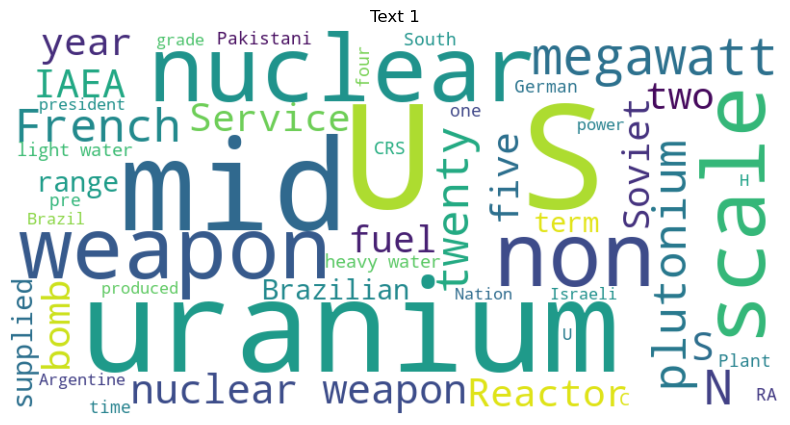

In [91]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(cloud_1)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Text 1")
plt.show()

In [92]:
cloud_2 = ' '.join(df_workset_2['word'].astype(str).tolist())

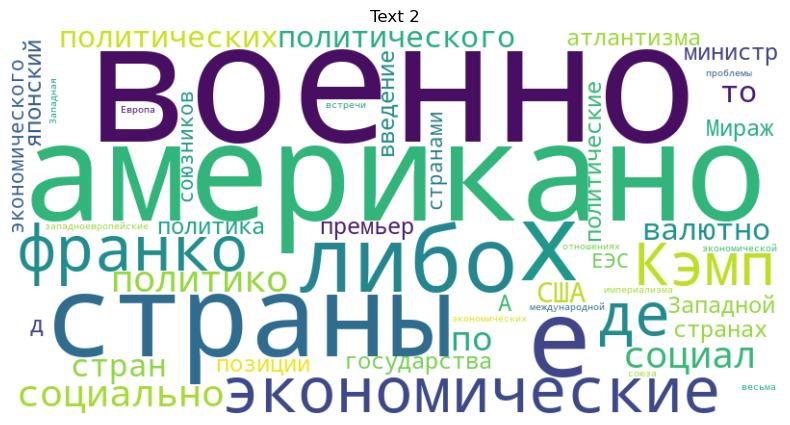

In [93]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(cloud_2)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Text 2")
plt.show()

# Frequency to Frequency Graph

In [96]:
fig = px.scatter(
    df_compare, 
    x="count_1", 
    y="count_2",
    text= df_compare['word_1']+", "+df_compare['word_2'],
    color="Similarity",
    log_x=True, 
    log_y=True,
    color_continuous_scale='RdBu_r', 
    color_continuous_midpoint=0,     
    labels={
        "count_1": "Occurrences in Text 1",
        "count_2": "Occurrences in Text 2"
    },
    title="Word Usage Comparison"
)

# Styling to match the screenshot
fig.update_traces(textposition='top center')
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey'),
)

fig.show()